In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2025-11-24 02:03:10.080813: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763929990.094444   30911 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763929990.098773   30911 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763929990.110636   30911 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763929990.110663   30911 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763929990.110665   30911 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Num GPUs Available:  1


In [ ]:
# 1. Load Data
df = pd.read_csv("dataset/train.csv")

# 2. Pivot Data to Wide Format (One row per image, 5 target columns)
# We need to pivot on 'image_path' (or sample_id) and 'target_name'
pivot_df = df.pivot_table(index='image_path', columns='target_name', values='target').reset_index()

# Ensure columns are in a consistent order
target_cols = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
pivot_df = pivot_df[['image_path'] + target_cols]

# Fill NaNs if any (though dataset seems complete, good practice)
pivot_df[target_cols] = pivot_df[target_cols].fillna(0.0)

print("Pivoted Shape:", pivot_df.shape)
display(pivot_df.head())

Pivoted Shape: (357, 6)


target_name,image_path,Dry_Green_g,Dry_Dead_g,Dry_Clover_g,GDM_g,Dry_Total_g
0,train/ID1011485656.jpg,16.2751,31.9984,0.0000,16.2750,48.2735
1,train/ID1012260530.jpg,7.6000,0.0000,0.0000,7.6000,7.6000
2,train/ID1025234388.jpg,0.0000,0.0000,6.0500,6.0500,6.0500
3,train/ID1028611175.jpg,24.2376,30.9703,0.0000,24.2376,55.2079
4,train/ID1035947949.jpg,10.5261,23.2239,0.4343,10.9605,34.1844


In [3]:
# 3. Split Data
train_df, val_df = train_test_split(pivot_df, test_size=0.2, random_state=42)

print("Train images:", len(train_df))
print("Val images:", len(val_df))

Train images: 285
Val images: 72


In [4]:
# 4. Create TensorFlow Dataset
IMG_SIZE = 512
BATCH_SIZE = 8

def load_image(path):
    # Load and preprocess image
    img = tf.io.read_file("dataset/" + path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def create_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    # Inputs: Image paths
    image_paths = dataframe['image_path'].values
    
    # Outputs: 5 Target values
    targets = dataframe[target_cols].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((image_paths, targets))
    
    def map_func(path, target):
        return load_image(path), target
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
        
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)

# Verify shapes
for img_batch, target_batch in train_ds.take(1):
    print("Image batch shape:", img_batch.shape)
    print("Target batch shape:", target_batch.shape)
    print("Sample targets:", target_batch[0].numpy())

I0000 00:00:1763929992.274558   30911 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5542 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Image batch shape: (8, 512, 512, 3)
Target batch shape: (8, 5)
Sample targets: [12.6389 33.0159  0.     12.6389 45.6548]


2025-11-24 02:03:13.186327: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# 4. Create TensorFlow Dataset
IMG_SIZE = 512
BATCH_SIZE = 8

def load_image(path):
    # Load and preprocess image
    img = tf.io.read_file("dataset/" + path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def create_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    # Inputs: Image paths
    image_paths = dataframe['image_path'].values
    
    # Outputs: 5 Target values
    targets = dataframe[target_cols].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((image_paths, targets))
    
    def map_func(path, target):
        return load_image(path), target
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
        
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)

# Verify shapes
for img_batch, target_batch in train_ds.take(1):
    print("Image batch shape:", img_batch.shape)
    print("Target batch shape:", target_batch.shape)
    print("Sample targets:", target_batch[0].numpy())

I0000 00:00:1763929992.274558   30911 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5542 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Image batch shape: (8, 512, 512, 3)
Target batch shape: (8, 5)
Sample targets: [12.6389 33.0159  0.     12.6389 45.6548]


2025-11-24 02:03:13.186327: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
for image, targets in train_ds.take(1):
    print(targets)

tf.Tensor(
[[  3.788   12.3111  35.0394  38.8275  51.1386]
 [ 21.0896  13.0842   0.      21.0896  34.1738]
 [ 16.8777  17.8286   6.8937  23.7714  41.6   ]
 [ 47.2541   1.8459   0.      47.2541  49.1   ]
 [ 31.3284   4.3212   0.      31.3285  35.6496]
 [ 74.0593  83.8407   0.      74.0593 157.9   ]
 [ 55.6108   8.6892   0.      55.6108  64.3   ]
 [ 46.5727   6.7982   1.3191  47.8918  54.69  ]], shape=(8, 5), dtype=float32)


2025-11-24 02:03:13.983897: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


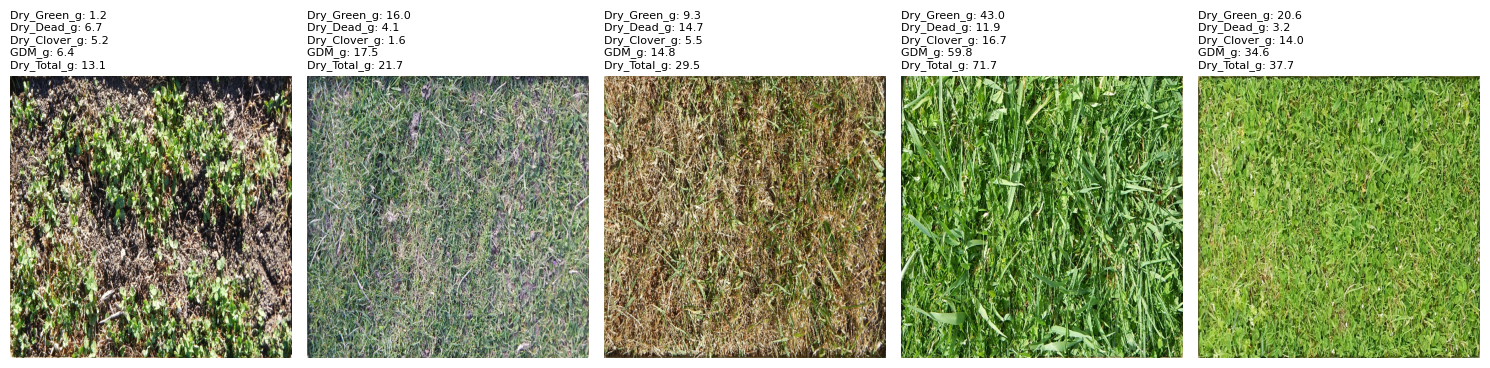

In [6]:
import matplotlib.pyplot as plt

target_names = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']

plt.figure(figsize=(15, 5))
for images, targets in train_ds.take(1):
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy())
        
        # Create a string for the targets
        t = targets[i].numpy()
        title_str = "\n".join([f"{n}: {v:.1f}" for n, v in zip(target_names, t)])
        
        plt.title(title_str, fontsize=8, loc='left')
        plt.axis("off")
plt.tight_layout()
plt.show()

## BUILDING THE MODEL NOW

In [7]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, SeparableConv2D, BatchNormalization, ReLU, Add,
    GlobalAveragePooling2D, Dense, Dropout, Input, Multiply, Reshape
)
from tensorflow.keras.models import Model

# Assuming IMG_SIZE is defined in your notebook, e.g., IMG_SIZE = 512

def conv_bn_relu(x, filters, kernel=3, stride=1):
    x = Conv2D(filters, kernel, strides=stride, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x

def depthwise_block(x, filters, stride=1):
    x = SeparableConv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x

def residual_block(x, filters, stride=1):
    shortcut = x

    # FIX: Apply stride to the first block
    x = depthwise_block(x, filters, stride=stride)
    x = depthwise_block(x, filters, stride=1)

    # Adjust shortcut if dimensions change
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def squeeze_excitation(x, reduction=16):
    filters = x.shape[-1]
    se = GlobalAveragePooling2D()(x)
    se = Dense(filters // reduction, activation="relu")(se)
    se = Dense(filters, activation="sigmoid")(se)
    se = Reshape((1, 1, filters))(se)
    return Multiply()([x, se])

# ------------------------------------------------------------
# FINAL CNN ARCH
# ------------------------------------------------------------

def build_improved_model(img_size=512):
    inputs = Input(shape=(img_size, img_size, 3), name="image_input")

    x = conv_bn_relu(inputs, 32, stride=2)
    x = residual_block(x, 32)

    x = conv_bn_relu(x, 64, stride=1) # Changed stride to 1 to avoid too aggressive downsampling early on, or keep as user designed
    # User had: x = conv_bn_relu(x, 64); x = residual_block(x, 64, stride=2)
    # Let's stick to user's pattern but be explicit
    
    # Stage 1
    x = conv_bn_relu(x, 64, stride=1) 
    x = residual_block(x, 64, stride=2) # Downsample

    # Stage 2
    x = conv_bn_relu(x, 128, stride=1)
    x = residual_block(x, 128, stride=2) # Downsample

    # Stage 3
    x = conv_bn_relu(x, 256, stride=1)
    x = residual_block(x, 256, stride=2) # Downsample

    # Stage 4
    x = conv_bn_relu(x, 512, stride=1)
    x = residual_block(x, 512, stride=2) # Downsample

    x = squeeze_excitation(x)

    # Global pooling + head
    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation="relu")(x)
    x = Dropout(0.25)(x)

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.15)(x)

    x = Dense(128, activation="relu")(x)

    outputs = Dense(5)(x)

    model = Model(inputs, outputs)
    return model

model = build_improved_model(IMG_SIZE)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 256,  │      1,312 │ re_lu[0][0]       │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 256,  │      1,312 │ re_lu_1[0][0]     │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ re_lu_2[0][0],    │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 256, 256,  │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     18,432 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     36,864 │ re_lu_4[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_2[0][0]  

 Total params: 3,145,669 (12.00 MB)

 Trainable params: 3,137,669 (11.97 MB)

 Non-trainable params: 8,000 (31.25 KB)

# we will assign weights to the output parameters

In [8]:
import tensorflow.keras.backend as K

def weighted_r2(y_true, y_pred):
    # Weights for the 5 biomass components
    # Dry_Green_g, Dry_Dead_g, Dry_Clover_g, GDM_g, Dry_Total_g
    weights = tf.constant([0.1, 0.1, 0.1, 0.2, 0.5], dtype=tf.float32)
    
    # Total Sum of Squares (TSS)
    mean_y_true = K.mean(y_true, axis=0)
    tss = K.sum(K.square(y_true - mean_y_true), axis=0)
    
    # Residual Sum of Squares (RSS)
    rss = K.sum(K.square(y_true - y_pred), axis=0)
    
    # R2 for each component: 1 - (RSS / (TSS + epsilon))
    # Adding epsilon to avoid division by zero
    r2_scores = 1 - (rss / (tss + K.epsilon()))
    
    # Weighted Average R2
    weighted_r2_score = K.sum(r2_scores * weights)
    
    return weighted_r2_score

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae', weighted_r2]
)


In [9]:
# Callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras', 
    monitor='val_weighted_r2', 
    mode='max', 
    save_best_only=True, 
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_weighted_r2', 
    mode='max', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_weighted_r2', 
    mode='max', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6,
    verbose=1
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    # callbacks=[checkpoint, early_stopping, reduce_lr]
)


Epoch 1/50


I0000 00:00:1763930002.785579   30996 service.cc:152] XLA service 0x75aed0045e50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763930002.785600   30996 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-11-24 02:03:22.966521: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763930004.049679   30996 cuda_dnn.cc:529] Loaded cuDNN version 91002
2025-11-24 02:03:25.071987: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6019', 40 bytes spill stores, 40 bytes spill loads

2025-11-24 02:03:25.102421: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusio

 1/36 ━━━━━━━━━━━━━━━━━━━━ 20:33 35s/step - loss: 1170.1484 - mae: 23.9613 - weighted_r2: -1.9271

I0000 00:00:1763930030.887438   30996 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 1280.5239 - mae: 24.5778 - weighted_r2: -2.7860

2025-11-24 02:03:57.259260: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6019', 40 bytes spill stores, 40 bytes spill loads

2025-11-24 02:03:58.031532: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6080', 8 bytes spill stores, 8 bytes spill loads

2025-11-24 02:03:58.067046: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6080', 104 bytes spill stores, 104 bytes spill loads

2025-11-24 02:03:59.916733: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-24 02:04:00.015279: E external/local_

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - loss: 1279.0294 - mae: 24.5546 - weighted_r2: -2.7865

2025-11-24 02:04:18.488715: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_583', 64 bytes spill stores, 64 bytes spill loads



36/36 ━━━━━━━━━━━━━━━━━━━━ 65s 842ms/step - loss: 1226.7236 - mae: 23.7442 - weighted_r2: -2.8049 - val_loss: 1071.3710 - val_mae: 23.3050 - val_weighted_r2: -3.4661
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - loss: 763.3087 - mae: 17.5031 - weighted_r2: -1.1324 - val_loss: 858.4484 - val_mae: 20.0620 - val_weighted_r2: -2.3465
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 141ms/step - loss: 479.1826 - mae: 14.9496 - weighted_r2: -0.3279 - val_loss: 897.9234 - val_mae: 20.6692 - val_weighted_r2: -2.5368
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - loss: 429.5041 - mae: 14.3025 - weighted_r2: -0.9820 - val_loss: 826.9512 - val_mae: 19.5716 - val_weighted_r2: -2.1645
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - loss: 414.9880 - mae: 13.9461 - weighted_r2: -1.7002 - val_loss: 777.6870 - val_mae: 18.8230 - val_weighted_r2: -1.9098
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - loss: 366.1847 - mae: 13.1164 - weighted_r2: -0.4177 - val_loss: 819.5962 - val_mae:

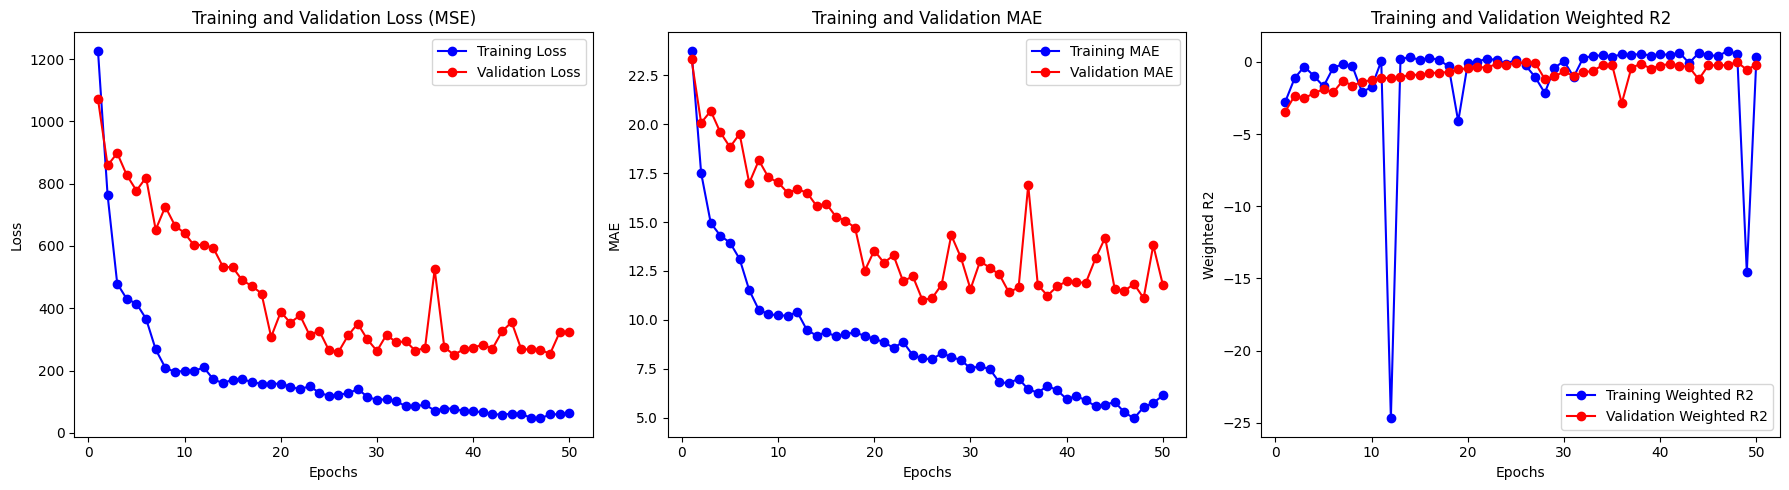

In [10]:
import matplotlib.pyplot as plt

def plot_history(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    r2 = history.history['weighted_r2']
    val_r2 = history.history['val_weighted_r2']
    
    epochs = range(1, len(loss) + 1)
    
    plt.figure(figsize=(18, 5))
    
    # Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot MAE
    plt.subplot(1, 3, 2)
    plt.plot(epochs, mae, 'bo-', label='Training MAE')
    plt.plot(epochs, val_mae, 'ro-', label='Validation MAE')
    plt.title('Training and Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    
    # Plot Weighted R2
    plt.subplot(1, 3, 3)
    plt.plot(epochs, r2, 'bo-', label='Training Weighted R2')
    plt.plot(epochs, val_r2, 'ro-', label='Validation Weighted R2')
    plt.title('Training and Validation Weighted R2')
    plt.xlabel('Epochs')
    plt.ylabel('Weighted R2')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)


In [ ]:
model.save("model6.h5")

Generating predictions for validation set...


2025-11-24 02:09:10.093499: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Overall Weighted R2 Score: 0.0896
Component R2 Scores:
  Dry_Green_g    : 0.1327
  Dry_Dead_g     : -0.0484
  Dry_Clover_g   : 0.1545
  GDM_g          : 0.2965
  Dry_Total_g    : 0.0129

Visualizing 5 random samples...


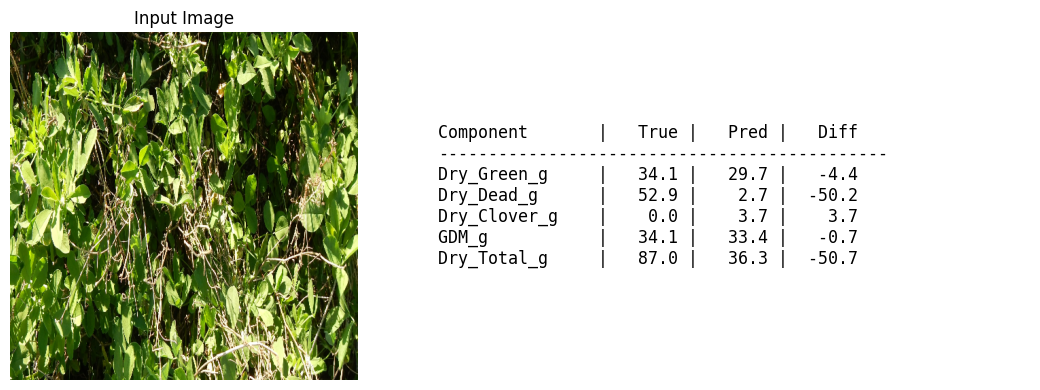

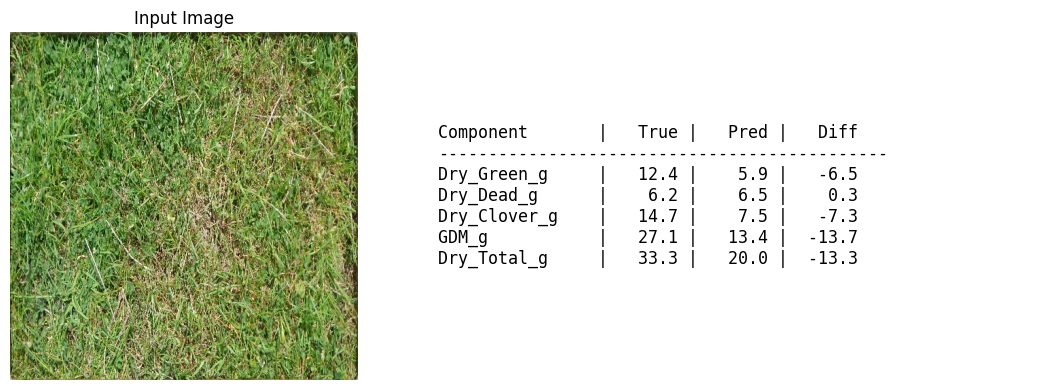

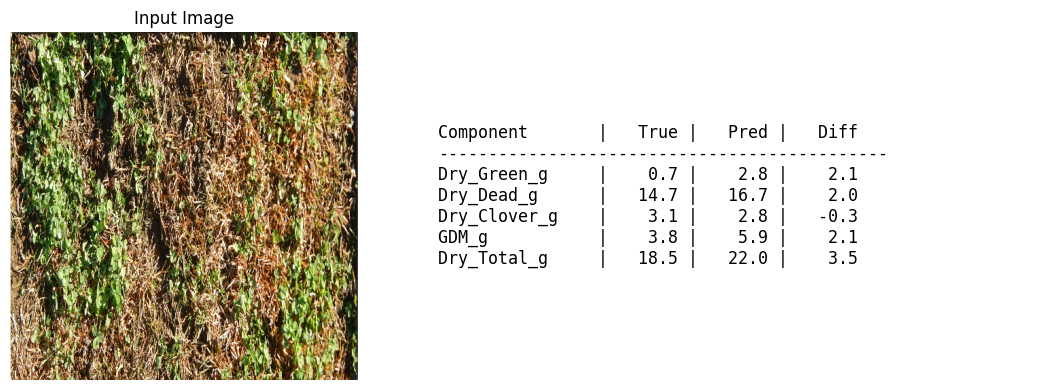

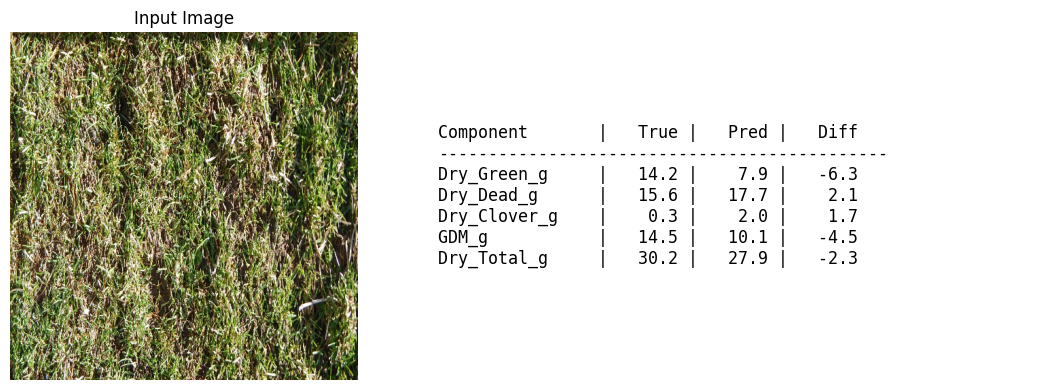

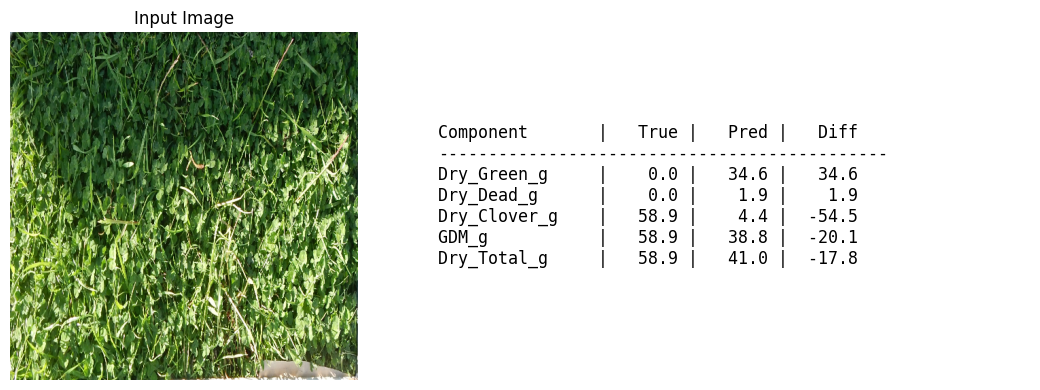

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_and_visualize(model, val_ds, num_samples=5):
    # 1. Get all predictions and true values
    all_images = []
    all_targets = []
    all_preds = []
    
    print("Generating predictions for validation set...")
    # Unbatch the dataset to process all samples
    for images, targets in val_ds:
        preds = model.predict(images, verbose=0)
        all_images.append(images.numpy())
        all_targets.append(targets.numpy())
        all_preds.append(preds)
        
    # Concatenate batches
    all_images = np.concatenate(all_images, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    
    # 2. Calculate Overall Weighted R2
    weights = np.array([0.1, 0.1, 0.1, 0.2, 0.5])
    
    mean_true = np.mean(all_targets, axis=0)
    tss = np.sum((all_targets - mean_true)**2, axis=0)
    rss = np.sum((all_targets - all_preds)**2, axis=0)
    
    # Avoid division by zero
    r2_scores = 1 - (rss / (tss + 1e-7))
    weighted_r2 = np.sum(r2_scores * weights)
    
    print(f"\nOverall Weighted R2 Score: {weighted_r2:.4f}")
    print(f"Component R2 Scores:")
    target_names = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    for name, score in zip(target_names, r2_scores):
        print(f"  {name:<15}: {score:.4f}")
        
    # 3. Visualize Samples
    print(f"\nVisualizing {num_samples} random samples...")
    indices = np.random.choice(len(all_images), num_samples, replace=False)
    
    for idx in indices:
        img = all_images[idx]
        true = all_targets[idx]
        pred = all_preds[idx]
        
        plt.figure(figsize=(12, 4))
        
        # Image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Input Image")
        
        # Table of values
        plt.subplot(1, 2, 2)
        plt.axis('off')
        
        # Header
        text_str = f"{'Component':<15} | {'True':>6} | {'Pred':>6} | {'Diff':>6}\n"
        text_str += "-"*45 + "\n"
        
        # Rows
        for i, name in enumerate(target_names):
            diff = pred[i] - true[i]
            text_str += f"{name:<15} | {true[i]:6.1f} | {pred[i]:6.1f} | {diff:6.1f}\n"
            
        plt.text(0, 0.5, text_str, fontsize=12, family='monospace', va='center')
        plt.tight_layout()
        plt.show()

# Run evaluation
evaluate_and_visualize(model, val_ds)


In [14]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os

def generate_submission(model):
    print("Loading test data...")
    test_df = pd.read_csv("dataset/test.csv")
    
    # Get unique images to predict on
    unique_images = test_df['image_path'].unique()
    print(f"Found {len(unique_images)} unique test images.")
    
    # Create Dataset
    def load_image(path):
        # Check if path exists
        full_path = "dataset/" + path
        img = tf.io.read_file(full_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0
        return img

    test_ds = tf.data.Dataset.from_tensor_slices(unique_images)
    test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    print("Predicting...")
    # Predict
    predictions = model.predict(test_ds, verbose=1)
    
    # Map predictions to image paths
    # predictions shape: (N_images, 5)
    # Target order: ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    target_cols = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    
    # Create a lookup dictionary: image_path -> {target_name: value}
    pred_dict = {}
    for img_path, pred_row in zip(unique_images, predictions):
        pred_dict[img_path] = {col: val for col, val in zip(target_cols, pred_row)}
        
    print("Formatting submission...")
    # Create submission rows
    submission_rows = []
    for index, row in test_df.iterrows():
        img_path = row['image_path']
        target_name = row['target_name']
        sample_id = row['sample_id']
        
        # Get prediction
        if img_path in pred_dict:
            pred_value = pred_dict[img_path][target_name]
        else:
            # Fallback if something went wrong (shouldn't happen)
            pred_value = 0.0
        
        # Ensure non-negative (biomass can't be negative)
        pred_value = max(0.0, pred_value)
        
        submission_rows.append({'sample_id': sample_id, 'target': pred_value})
        
    submission_df = pd.DataFrame(submission_rows)
    
    # Save to CSV
    output_file = "submission.csv"
    submission_df.to_csv(output_file, index=False)
    print(f"Saved submission to {output_file}")
    
    # Print the content for user to copy if needed
    print("\n" + "="*20 + " SUBMISSION CSV CONTENT " + "="*20)
    print(submission_df.to_csv(index=False))
    print("="*64)

# Run generation
generate_submission(model)


Loading test data...
Found 1 unique test images.
Predicting...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Formatting submission...
Saved submission to submission.csv

==================== SUBMISSION CSV CONTENT ====================
sample_id,target
ID1001187975__Dry_Clover_g,1.6541297
ID1001187975__Dry_Dead_g,17.173973
ID1001187975__Dry_Green_g,7.090298
ID1001187975__Dry_Total_g,25.98739
ID1001187975__GDM_g,8.885671



In [22]:
import tensorflow as tf
from tensorflow.keras.activations import gelu
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

IMG_SIZE = 512


# -------- DropPath Layer ----------
class DropPath(Layer):
    def __init__(self, drop_prob=0.0, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob

    def call(self, x, training=None):
        if (not training) or self.drop_prob == 0:
            return x

        keep_prob = 1.0 - self.drop_prob
        shape = (tf.shape(x)[0],) + (1,) * (len(x.shape) - 1)

        random_tensor = keep_prob + tf.random.uniform(shape, dtype=x.dtype)
        random_tensor = tf.floor(random_tensor)

        return (x / keep_prob) * random_tensor


# -------- ConvNeXt Block ----------
def convnext_block(x, filters, drop_rate=0.0):
    shortcut = x

    x = DepthwiseConv2D(kernel_size=7, padding="same")(x)
    x = LayerNormalization(epsilon=1e-6)(x)

    x = Dense(filters * 4)(x)
    x = Activation(gelu)(x)
    x = Dense(filters)(x)

    # Now safe
    x = DropPath(drop_rate)(x)

    x = Add()([shortcut, x])
    return x


# -------- SE Block ----------
def squeeze_excitation(x, reduction=16):
    c = x.shape[-1]
    se = GlobalAveragePooling2D()(x)
    se = Dense(c // reduction, activation="relu")(se)
    se = Dense(c, activation="sigmoid")(se)
    se = Reshape((1, 1, c))(se)
    return Multiply()([x, se])


# -------- Full Model ----------
def build_insane_model(img_size=512):
    inputs = Input(shape=(img_size, img_size, 3))

    # Aggressive stem
    x = Conv2D(64, 4, strides=4, padding="same")(inputs)
    x = LayerNormalization()(x)

    config = [
        (128, 3),
        (256, 4),
        (512, 6),
        (768, 3),
        (1024, 2)
    ]

    drop_rate = 0.05

    for filters, blocks in config:
        x = Conv2D(filters, 3, strides=2, padding="same")(x)
        for _ in range(blocks):
            x = convnext_block(x, filters, drop_rate)
        x = squeeze_excitation(x)
        drop_rate += 0.02

    x = GlobalAveragePooling2D()(x)

    # Dense head
    for units, dr in [(2048,0.4),(1024,0.3),(512,0.25),(256,0.15),(128,0.05)]:
        x = Dense(units, activation=gelu)(x)
        x = Dropout(dr)(x)

    x = Dense(128, activation="relu")(x)
    outputs = Dense(5)(x)

    return Model(inputs, outputs)


model = build_insane_model(IMG_SIZE)
model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 128, 128,  │      3,136 │ input_layer_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_28[0][0]   │
│ (LayerNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 64, 64,    │     73,856 │ layer_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_39 │ (None, 64, 64,    │      6,400 │ conv2d_29[0][0]   │
│ (DepthwiseConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64,    │        256 │ depthwise_conv2d… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_113 (Dense)   │ (None, 64, 64,    │     66,048 │ layer_normalizat… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_37       │ (None, 64, 64,    │          0 │ dense_113[0][0]   │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_114 (Dense)   │ (None, 64, 64,    │     65,664 │ activation_37[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_path_36        │ (None, 64, 64,    │          0 │ dense_114[0][0]   │
│ (DropPath)          │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_41 (Add)        │ (None, 64, 64,    │          0 │ conv2d_29[0][0],  │
│                     │ 128)              │            │ drop_path_36[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_40 │ (None, 64, 64,    │      6,400 │ add_41[0][0]      │
│ (DepthwiseConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64,    │        256 │ depthwise_conv2d… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_115 (Dense)   │ (None, 64, 64,    │     66,048 │ layer_normalizat… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 64, 64,    │          0 │ dense_115[0][0]   │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_116 (Dense)   │ (None, 64, 64,    │     65,664 │ activation_38[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_path_37        │ (None, 64, 64,    │          0 │ dense_116[0][0] 

 Total params: 63,834,989 (243.51 MB)

 Trainable params: 63,834,989 (243.51 MB)

 Non-trainable params: 0 (0.00 B)